<a href="https://colab.research.google.com/github/karrielaugustin001-del/Machine-Learning-Foundations/blob/main/In_Class_Activity_10_Generalization_Detective_Group_2_Executed_File.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generalization Detective - Student Starter Notebook

## Activity Goal
Use a realistic nonlinear classification dataset and pre-computed learning curves to determine whether each model is:
- underfitting,
- overfitting, or
- generalizing well.

## What you will do
1. Load and visualize the dataset
2. Plot the learning curves for Models A, B, and C
3. Diagnose model behavior using learning theory concepts
4. Propose strategies to improve generalization


## Setup and Data Loading

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data_candidates = [
    Path("nonlinear_classification_data.csv"),
    Path("/content/nonlinear_classification_data.csv"),
    Path("/mnt/data/generalization_detective_activity/nonlinear_classification_data.csv"),
    Path("/mnt/data/nonlinear_classification_data.csv"),
]

data_path = None
for p in data_candidates:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("Dataset not found. Please upload nonlinear_classification_data.csv.")

df = pd.read_csv(data_path)
print("Using dataset:", data_path)
print(df.head())
print(df.shape)


Using dataset: nonlinear_classification_data.csv
   feature1  feature2  feature3     noise  target
0  0.496714 -0.847519 -0.339247 -0.143423       0
1 -0.138264 -0.906828 -0.152750 -0.032656       0
2  0.647689 -3.591286 -0.298691  0.064295       0
3  1.523030 -0.660180  0.055209  0.946861       1
4 -0.234153  1.465658  0.598589 -0.747217       0
(5000, 5)


## Visualizing the Data
Create a scatter plot of `x1` vs `x2` colored by class label `y`.

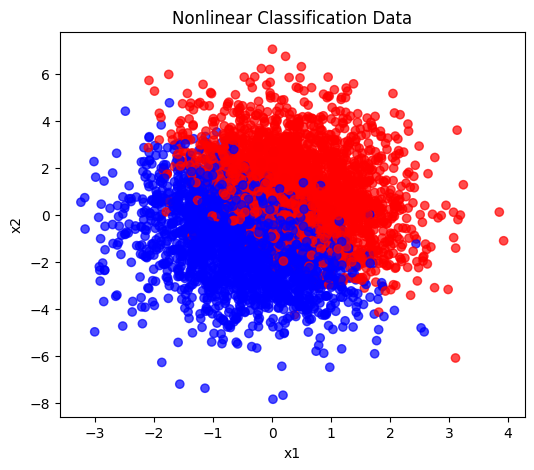

In [ ]:
# TODO: Create a scatter plot of x1 vs x2 colored by y
plt.figure(figsize=(6, 5))
plt.scatter(df["feature1"], df["feature2"], c=df["target"], cmap="bwr", alpha=0.7)
plt.title("Nonlinear Classification Data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

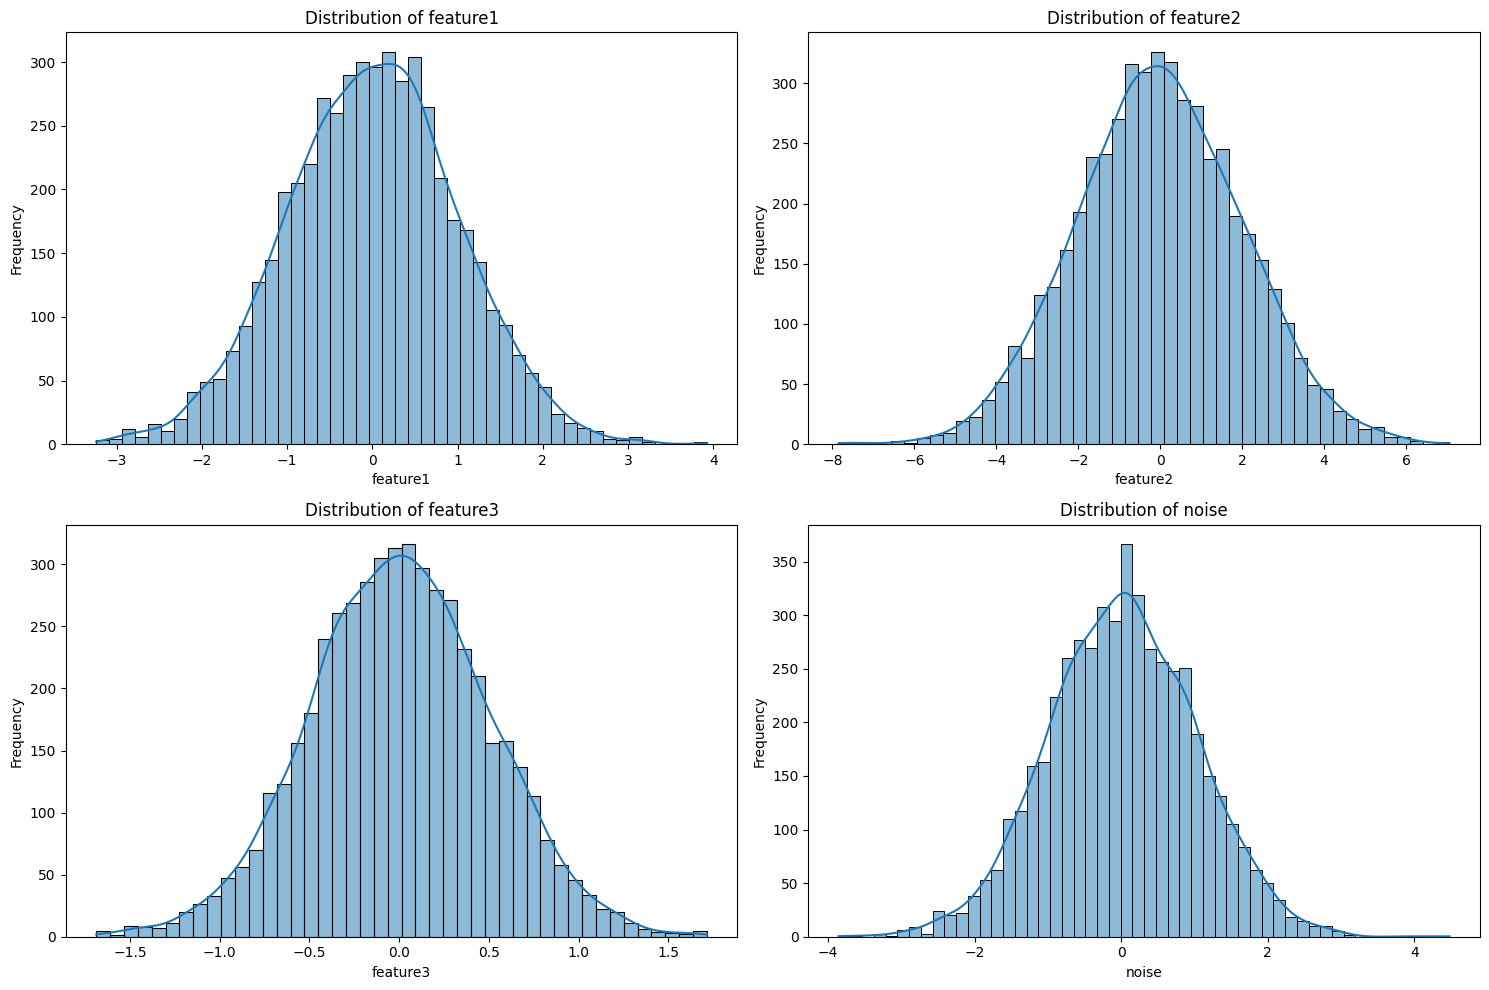

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get numerical features (excluding 'target' as it's a class label)
numerical_features = ['feature1', 'feature2', 'feature3', 'noise']

plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.histplot(df[feature], kde=True) # Use kde=True to show the kernel density estimate
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

These histograms show the distribution of each numerical feature in the dataset. The x-axis represents the range of values for the feature, and the y-axis represents the frequency or count of observations within each bin. The overlaid line is a Kernel Density Estimate (KDE), which provides a smoothed representation of the distribution.

## Pre-Computed Learning Curves
These arrays represent three different model behaviors. Your task is to interpret them.

In [ ]:

train_sizes = [100, 300, 600, 900, 1200]

# Model A: underfitting (high bias)
model_A_train_scores = [0.70, 0.72, 0.73, 0.73, 0.73]
model_A_val_scores   = [0.68, 0.69, 0.69, 0.68, 0.68]

# Model B: overfitting (high variance)
model_B_train_scores = [0.99, 0.99, 0.99, 0.99, 0.99]
model_B_val_scores   = [0.60, 0.62, 0.61, 0.59, 0.58]

# Model C: good generalization
model_C_train_scores = [0.90, 0.91, 0.91, 0.91, 0.91]
model_C_val_scores   = [0.88, 0.89, 0.89, 0.89, 0.88]

print("Learning curve arrays loaded.")


Learning curve arrays loaded.


## Plot the Learning Curves

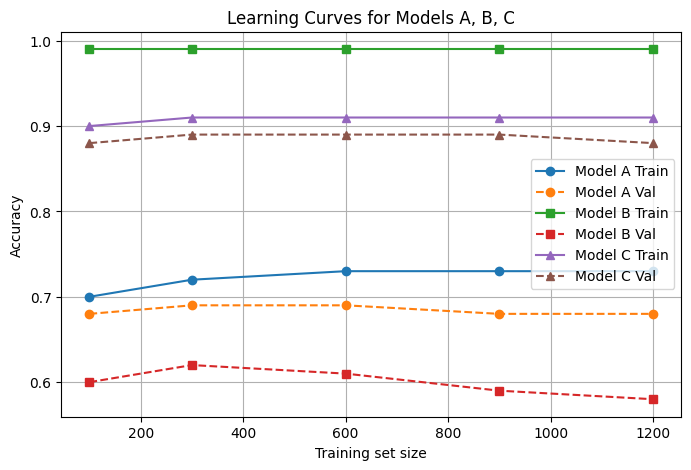

In [ ]:
# TODO: Plot learning curves for each model
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, model_A_train_scores, "o-", label="Model A Train")
plt.plot(train_sizes, model_A_val_scores, "o--", label="Model A Val")
plt.plot(train_sizes, model_B_train_scores, "s-", label="Model B Train")
plt.plot(train_sizes, model_B_val_scores, "s--", label="Model B Val")
plt.plot(train_sizes, model_C_train_scores, "^-", label="Model C Train")
plt.plot(train_sizes, model_C_val_scores, "^--", label="Model C Val")
plt.xlabel("Training set size")
plt.ylabel("Accuracy")
plt.title("Learning Curves for Models A, B, C")
plt.legend()
plt.grid(True)
plt.show()


## Analysis Questions - Write Your Responses Below

### 1. Which model is underfitting? Why?
**TODO:** Model A indicates that it did not learn from the training as it performed poorly on training data and tested poorly on unseen data. In other words, the underfit model is too simple and does not capture patterns in the data well.

### 2. Which model is overfitting? Why?
**TODO:** Model B suggests that it learned the training data too well by memorizing, which is different compared to Model A. In memorizing, Model B even learned noise along with the specific training data. The training score was perfect for Model B, but it performed poorly on the test, unseen data. We see a high variance performance between the training scores and the validation scores. It was confused because it did not follow the pattern and only memorized, resulting in an inability to handle unseen data.

### 3. Which model generalizes best?
**TODO:** Model C had high performance results in both training and validation scores. This signals that the model understood data and followed the general pattern. Understanding the general pattern, the Model C was able to perform well on new data. The high scores and low variance in error on both the training and validation performance indicated a balance between bias and variance. We also see balance in the performance as the sample size increases in comparison to the other models.

### 4. How does this relate to bias-variance and capacity?
**TODO:** **Bias-variance Tradeoff:**
	Model A was underfitting, which had a high bias and low variance. With the training and validation performance low, it was indicative that the model was too simple to learn the nonlinear classification dataset. In other words, the model was using a simple rule and did not learn patterns, which resulted in it making many mistakes. On the contrary, Model B was overfitting, which had a low bias and high variance. The low bias and high variance signaled that the model learns many details in the pattern, including the noise. The low bias indicated that the model was not using a simple rule. The model performed nearly perfect on training data because it was highly flexible and complex. Model C demonstrated good generalization. With generalization, there was a balance between bias and variance. The model was not too simple or too complex, but just right. The model did not memorize too much detail and was able to follow the general pattern.

**Hypothesis space:**
Model A with a high bias is learning in a too restrictive/small hypothesis space and cannot reach generalization. Model B with a high variance has a large hypothesis space and it has many functions/many possible decision boundaries that includes noise, which works against generalization.    Model C contains a hypothesis space that has a large enough decision boundary to capture the general pattern and ignore noise in the dataset. For Model C, the hypothesis space is the appropriate size in space for a successful generalization.

**Capacity:**
	Model A is a low capacity learner and can only learn simple rules and misses pattern details. Model B is a high capacity learner that can learn very detailed and complicated patterns and gathers non-relevant to the data. Model C has a balanced capacity, which means that the model learns the important patterns, avoids memorizing noise, and does well on training data and on unseen data (good generalization).   

**VC dimension intuition:**
	Model A has a low VC dimension intuition indicative of the model’s underfitting and high bias. The model cannot shatter or separate the points correctly because of the small hypothesis space (OpenAI, 2026). Model B has a high VC dimension like a deep neural network with a large hypothesis space. The model is too powerful and shatters the training data with near perfection. The flexibility has no boundaries. Since the dataset is dominated by noise, it creates a challenge for Model B’s performance on new/unseen data. Model C is the optimal VC dimension, in which it finds a balance in the bias and variance and is not too complex of a model with a medium/just right capacity. “VC dimension intuition helps explain model behavior by describing how flexible a model is: too low leads to underfitting, too high leads to overfitting, and a well-matched level supports strong generalization” (OpenAI, 2026).


### 5. Propose one strategy to improve each problematic model.
**TODO:** **For Model A,** we want to increase complexity/flexibility and reduce regularization to avoid further simplicity. We recommend expanding the hypothesis space. Adding more data is not the complete solution because the model is too weak. A simpler model is not recommended because it is too simple. Reducing noise is helpful, but not the main issue. The critical issue is that the model cannot capture nonlinear patterns.

  **For Model B,** it is recommended to increase regularization with Lasso and/or Ridge to control complexity and reduce/manage the memorization of noise. More data is helpful to reduce noise and randomness. A simpler model is also an improvement strategy to reduce variance and increase generalization. Noise reduction is beneficial because the dataset has noise as a feature.

  **For Model C,** the best model, it already has a balance between bias and variance along with the just right hypothesis space and capacity. The objective to improve would be focused on sustaining its strong performance and reliability in generalization. We would only do minor regularization tuning to avoid the modeling becoming too simple/underfitting. We do not want the model to become simpler to avoid hurting performance. Another suggested step would be to add more data to help make the model more robust, reliable and stable. Lastly, noise reduction is a valuable step with the potential risk of the noise feature influencing predictions.



## Reflection Questions

Write short responses to the following:
1. What key insights were revealed through your evaluation process? Through this activity, we learned that accuracy alone is not enough to evaluate a model. Learning curves are much more helpful because they show how a model behaves as it learns. High performance between training and validation accuracy is a sign of good generalization. A high training score and low validation/test score is a sign of overfitting. Low accuracy overall is a sign of underfitting.
2. Which model or technique provided the best results, and why? Model C is the optimal model because it has good generalization.
3. What were the main challenges faced during the analysis? 	Model A struggled with the nonlinear dataset because the model was too simple. This highlighted the impact of simple models and poor generalization. Model A also had tight decision boundaries. Compared to Model B, the decision boundaries were very wide making the model too complex. The complexity of Model B worked against generalization. There was a lack of regularization in Model B to improve performance on unseen data. Additionally, the noise in the data made the overly complex Model B memorize randomness instead of learning the true signals.
4. How do your findings demonstrate the bias-variance tradeoff? See above section 4.
5. What steps could improve model performance and reliability? See above section 5.


## Final Group Summary
**TODO:** Summarize your group's conclusions here. Include at least one observation about:
- model capacity,
- learning curve shape,
- generalization, and
- how the dataset's nonlinear structure affects model behavior.

**Challenges:**
	Model A struggled with the nonlinear dataset because the model was too simple. This highlighted the impact of simple models and poor generalization. Model A also had tight decision boundaries. Compared to Model B, the decision boundaries were very wide making the model too complex. The complexity of Model B worked against generalization. There was a lack of regularization in Model B to improve performance on unseen data. Additionally, the noise in the data made the overly complex Model B memorize randomness instead of learning the true signals. Furthermore, determining the right capacity in the models played a challenging role for Model A and B.

**Conclusion:**
In conclusion, this activity helped us understand how to diagnose model behavior using learning curves. Model A underfit the data due to low capacity, Model B overfit due to its complexity, and Model C achieved the best performance by balancing bias and variance. The nonlinear nature of the dataset required a model that was complex enough to capture patterns but not too complex to memorize noise. This highlights the importance of choosing the right model and using techniques like regularization to improve performance. Overall, we learned that the goal of machine learning is not just to perform well on training data, but to generalize effectively to new data. Learning curves are a powerful tool that helps us achieve this goal.
